In [ ]:
import zipfile

# Extract the ZIP file
with zipfile.ZipFile("banknote+authentication.zip", "r") as zip_ref:
    zip_ref.extractall("banknote_dataset")

In [ ]:
import pandas as pd

columns = ["Variance", "Skewness", "Curtosis", "Entropy", "Class"]

df = pd.read_csv(
    "banknote_dataset/data_banknote_authentication.txt",
    header=None,
    names=columns
)

print(df.head())

   Variance  Skewness  Curtosis  Entropy  Class
0   3.62160    8.6661   -2.8073 -0.44699      0
1   4.54590    8.1674   -2.4586 -1.46210      0
2   3.86600   -2.6383    1.9242  0.10645      0
3   3.45660    9.5228   -4.0112 -3.59440      0
4   0.32924   -4.4552    4.5718 -0.98880      0


In [ ]:
print("Dataset dimensions is ")
df.shape

Dataset dimensions is 


(1372, 5)

In [ ]:
df.isnull().sum()

,0
Variance,0
Skewness,0
Curtosis,0
Entropy,0
Class,0


In [ ]:
df.describe()

,Variance,Skewness,Curtosis,Entropy,Class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

# Optional: Improve plot appearance
sns.set(style="whitegrid")

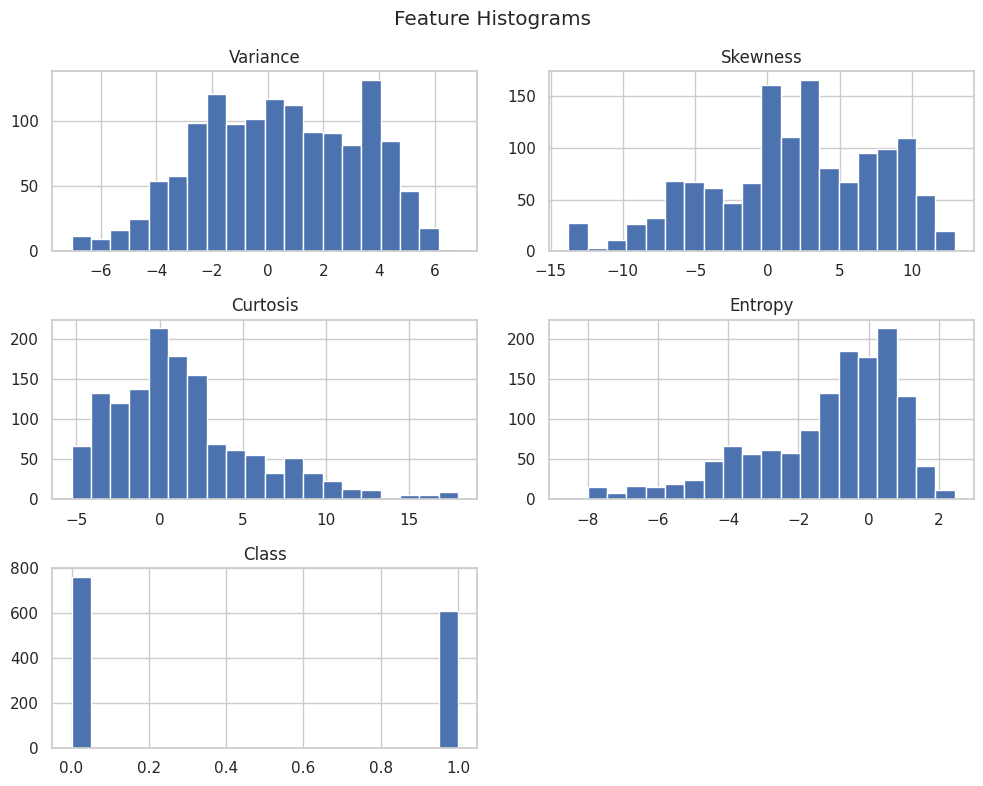

In [ ]:
df.hist(figsize=(10,8), bins=20)
plt.suptitle("Feature Histograms")
plt.tight_layout()
plt.show()

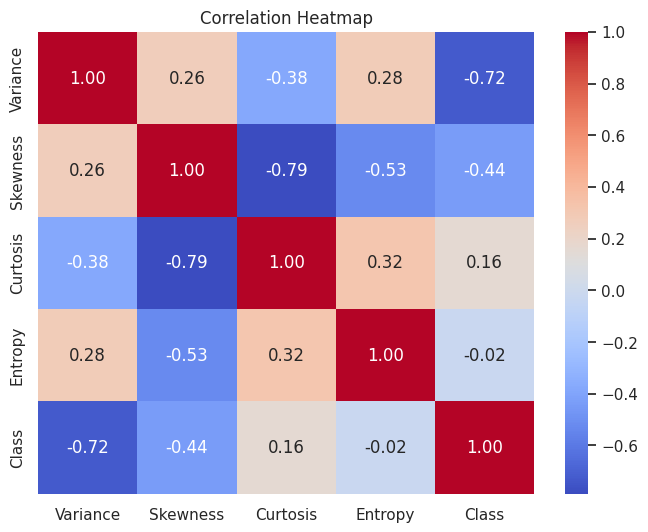

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

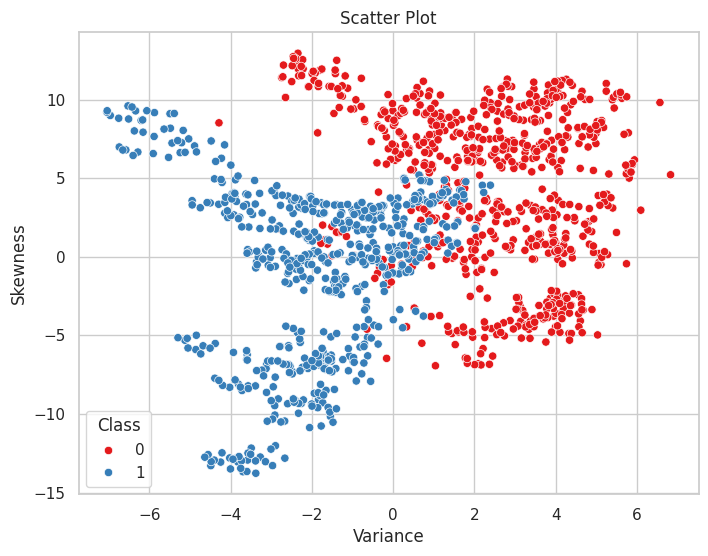

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Variance",
    y="Skewness",
    hue="Class",
    palette="Set1"
)

plt.title("Scatter Plot")
plt.show()

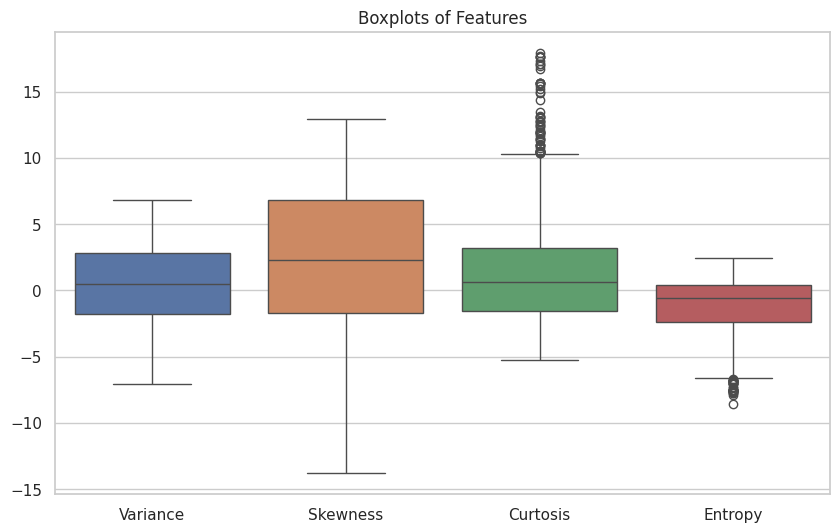

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df.iloc[:, :-1])

plt.title("Boxplots of Features")
plt.show()

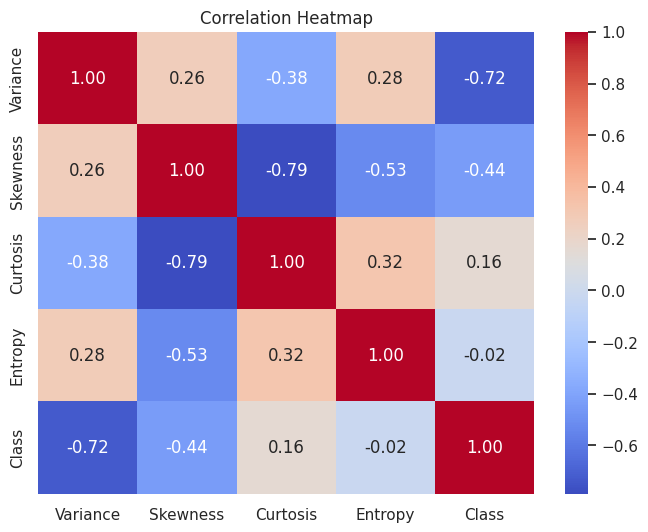

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")

plt.savefig("correlation_heatmap.eps", format="eps", bbox_inches="tight")

plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

# Features and target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Create scaler
scaler = StandardScaler()

# Normalize features
X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42
)

In [ ]:
#TO verify the split
print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Labels :", y_train.shape)
print("Testing Labels  :", y_test.shape)

Training Features: (1097, 4)
Testing Features : (275, 4)
Training Labels : (1097,)
Testing Labels  : (275,)


In [ ]:
import numpy as np

class Perceptron:

    def __init__(self, learning_rate=0.01, epochs=100):

        self.learning_rate = learning_rate
        self.epochs = epochs

    def activation(self, x):

        if x >= 0:
            return 1
        return 0

    def fit(self, X, y):

        n_samples, n_features = X.shape

        # Weight Initialization
        self.weights = np.zeros(n_features)

        # Bias Initialization
        self.bias = 0

        for epoch in range(self.epochs):

            for i in range(n_samples):

                linear_output = np.dot(X[i], self.weights) + self.bias

                prediction = self.activation(linear_output)

                update = self.learning_rate * (y[i] - prediction)

                self.weights += update * X[i]

                self.bias += update

    def predict(self, X):

        predictions = []

        for x in X:

            linear_output = np.dot(x, self.weights) + self.bias

            predictions.append(self.activation(linear_output))

        return np.array(predictions)

In [ ]:
X_train = np.array(X_train)
X_test = np.array(X_test)

y_train = np.array(y_train)
y_test = np.array(y_test)

In [ ]:
model = Perceptron(
    learning_rate=0.01,
    epochs=100
)

model.fit(X_train, y_train)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
#tASK 5
import numpy as np

class Perceptron:

    def __init__(self, learning_rate=0.01, epochs=20):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.errors = []

    # Step Activation Function
    def activation(self, z):
        if z >= 0:
            return 1
        else:
            return 0

    # Training Function
    def fit(self, X, y):

        # Convert to NumPy arrays
        X = np.array(X)
        y = np.array(y)

        n_samples, n_features = X.shape

        # Weight Initialization
        self.weights = np.zeros(n_features)

        # Bias Initialization
        self.bias = 0

        print("="*70)
        print("TRAINING STARTED")
        print("="*70)

        for epoch in range(self.epochs):

            misclassified = 0

            for i in range(n_samples):

                # Forward Propagation
                z = np.dot(X[i], self.weights) + self.bias

                prediction = self.activation(z)

                # Count misclassified samples
                if prediction != y[i]:
                    misclassified += 1

                # Perceptron Learning Rule
                update = self.learning_rate * (y[i] - prediction)

                self.weights += update * X[i]
                self.bias += update

            self.errors.append(misclassified)

            print(f"\nEpoch {epoch+1}/{self.epochs}")
            print("Misclassified Samples :", misclassified)
            print("Updated Weights       :", self.weights)
            print("Updated Bias          :", self.bias)

        print("\nTraining Completed!")

    # Prediction Function
    def predict(self, X):

        X = np.array(X)

        predictions = []

        for x in X:

            z = np.dot(x, self.weights) + self.bias

            predictions.append(self.activation(z))

        return np.array(predictions)

In [ ]:
model = Perceptron(
    learning_rate=0.01,
    epochs=20
)

model.fit(X_train, y_train)

TRAINING STARTED

Epoch 1/20
Misclassified Samples : 47
Updated Weights       : [-0.07253688 -0.06486266 -0.06445982  0.00019858]
Updated Bias          : -0.03

Epoch 2/20
Misclassified Samples : 26
Updated Weights       : [-0.08217015 -0.09380199 -0.05149354 -0.00518242]
Updated Bias          : -0.03

Epoch 3/20
Misclassified Samples : 34
Updated Weights       : [-0.09467641 -0.09140031 -0.08905542 -0.00956468]
Updated Bias          : -0.05

Epoch 4/20
Misclassified Samples : 23
Updated Weights       : [-0.11074483 -0.09580878 -0.10630688 -0.01312422]
Updated Bias          : -0.04

Epoch 5/20
Misclassified Samples : 27
Updated Weights       : [-0.13096386 -0.12179581 -0.09112828 -0.00877065]
Updated Bias          : -0.05

Epoch 6/20
Misclassified Samples : 25
Updated Weights       : [-0.13953409 -0.12843016 -0.10488173 -0.00669071]
Updated Bias          : -0.04

Epoch 7/20
Misclassified Samples : 19
Updated Weights       : [-0.1352697  -0.14036924 -0.10526858 -0.00515692]
Updated Bias

In [ ]:
y_pred = model.predict(X_test)

print("First 10 Predictions:")
print(y_pred[:10])

First 10 Predictions:
[0 0 0 0 0 0 0 0 0 0]


MODEL EVALUATION
Accuracy : 0.9636
Precision: 1.0000
Recall   : 0.9213
F1-Score : 0.9590

Confusion Matrix
[[148   0]
 [ 10 117]]


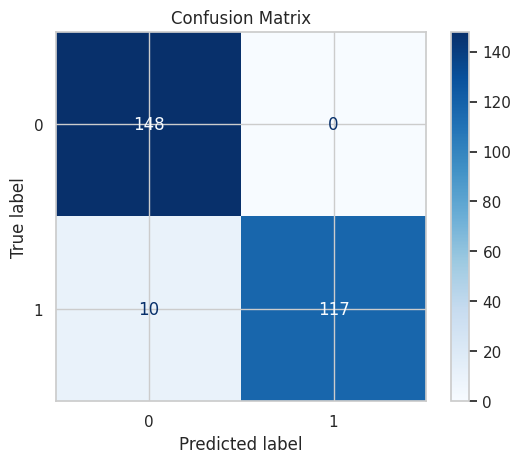

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

# Predictions on test data
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Precision
precision = precision_score(y_test, y_pred)

# Recall
recall = recall_score(y_test, y_pred)

# F1 Score
f1 = f1_score(y_test, y_pred)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("="*50)
print("MODEL EVALUATION")
print("="*50)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

print("\nConfusion Matrix")
print(cm)

# Plot Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

# Save as EPS
plt.savefig("confusion_matrix.eps", format="eps", bbox_inches="tight")

plt.show()

In [ ]:
#TASK 7
import numpy as np

class Perceptron:

    def __init__(self, learning_rate=0.01, epochs=20):

        self.learning_rate = learning_rate
        self.epochs = epochs

        self.weights = None
        self.bias = None

        # For plots
        self.errors = []
        self.weight_history = []
        self.bias_history = []

    # Step Activation Function
    def activation(self, x):

        if x >= 0:
            return 1
        else:
            return 0

    # Training
    def fit(self, X, y):

        X = np.array(X)
        y = np.array(y)

        n_samples, n_features = X.shape

        # Weight Initialization
        self.weights = np.zeros(n_features)

        # Bias Initialization
        self.bias = 0

        print("="*60)
        print("TRAINING STARTED")
        print("="*60)

        for epoch in range(self.epochs):

            misclassified = 0

            for i in range(n_samples):

                # Forward Propagation
                z = np.dot(X[i], self.weights) + self.bias

                prediction = self.activation(z)

                if prediction != y[i]:
                    misclassified += 1

                # Perceptron Learning Rule
                update = self.learning_rate * (y[i] - prediction)

                self.weights += update * X[i]

                self.bias += update

            # Store values for plots
            self.errors.append(misclassified)
            self.weight_history.append(self.weights.copy())
            self.bias_history.append(self.bias)

            print(f"\nEpoch {epoch+1}/{self.epochs}")
            print("Misclassified Samples :", misclassified)
            print("Updated Weights       :", self.weights)
            print("Updated Bias          :", self.bias)

        print("\nTraining Completed.")

    # Prediction
    def predict(self, X):

        X = np.array(X)

        predictions = []

        for x in X:

            z = np.dot(x, self.weights) + self.bias

            predictions.append(self.activation(z))

        return np.array(predictions)

In [ ]:
model = Perceptron(
    learning_rate=0.01,
    epochs=20
)

model.fit(X_train, y_train)

TRAINING STARTED

Epoch 1/20
Misclassified Samples : 47
Updated Weights       : [-0.07253688 -0.06486266 -0.06445982  0.00019858]
Updated Bias          : -0.03

Epoch 2/20
Misclassified Samples : 26
Updated Weights       : [-0.08217015 -0.09380199 -0.05149354 -0.00518242]
Updated Bias          : -0.03

Epoch 3/20
Misclassified Samples : 34
Updated Weights       : [-0.09467641 -0.09140031 -0.08905542 -0.00956468]
Updated Bias          : -0.05

Epoch 4/20
Misclassified Samples : 23
Updated Weights       : [-0.11074483 -0.09580878 -0.10630688 -0.01312422]
Updated Bias          : -0.04

Epoch 5/20
Misclassified Samples : 27
Updated Weights       : [-0.13096386 -0.12179581 -0.09112828 -0.00877065]
Updated Bias          : -0.05

Epoch 6/20
Misclassified Samples : 25
Updated Weights       : [-0.13953409 -0.12843016 -0.10488173 -0.00669071]
Updated Bias          : -0.04

Epoch 7/20
Misclassified Samples : 19
Updated Weights       : [-0.1352697  -0.14036924 -0.10526858 -0.00515692]
Updated Bias

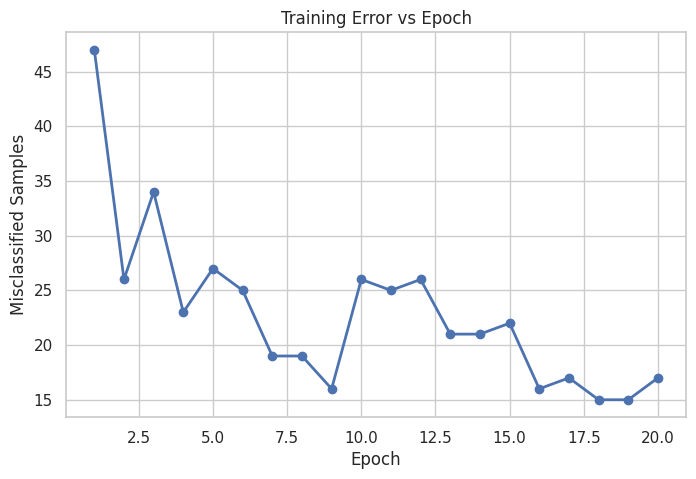

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(range(1, len(model.errors)+1),
         model.errors,
         marker='o',
         linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Misclassified Samples")
plt.title("Training Error vs Epoch")

plt.grid(True)

plt.savefig("training_error.eps",
            format="eps",
            bbox_inches="tight")

plt.show()

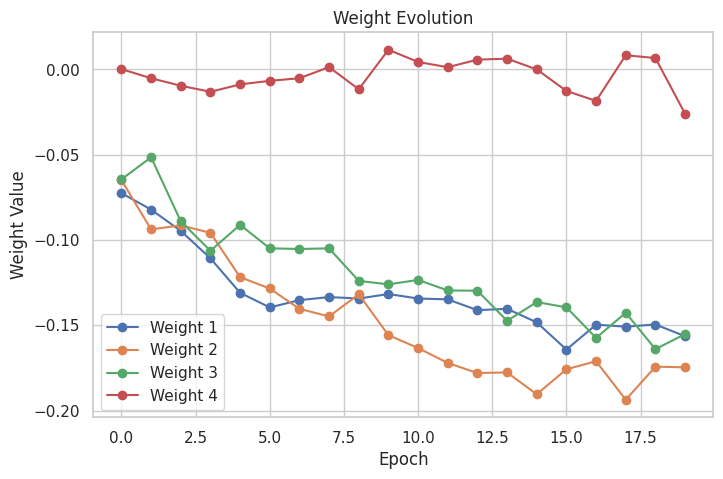

In [ ]:
weights = np.array(model.weight_history)

plt.figure(figsize=(8,5))

for i in range(weights.shape[1]):
    plt.plot(weights[:, i],
             marker='o',
             label=f"Weight {i+1}")

plt.xlabel("Epoch")
plt.ylabel("Weight Value")
plt.title("Weight Evolution")

plt.legend()
plt.grid(True)

plt.savefig("weight_evolution.eps",
            format="eps",
            bbox_inches="tight")

plt.show()

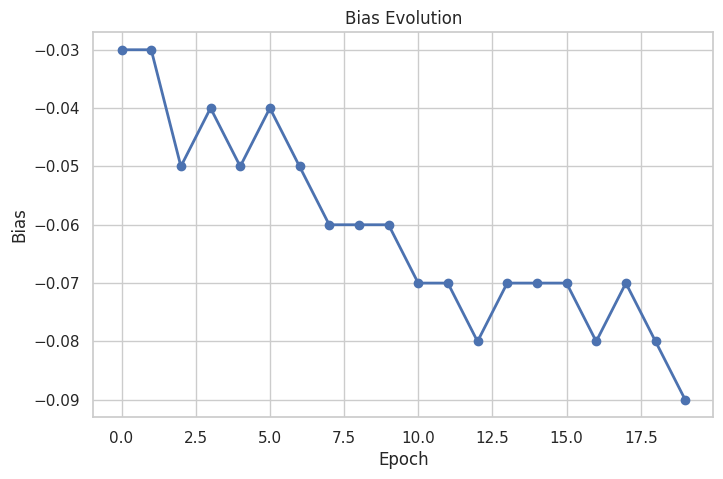

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(model.bias_history,
         marker='o',
         linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Bias")

plt.title("Bias Evolution")

plt.grid(True)

plt.savefig("bias_evolution.eps",
            format="eps",
            bbox_inches="tight")

plt.show()

TRAINING STARTED

Epoch 1/20
Misclassified Samples : 47
Updated Weights       : [-7.25368818e-03 -6.48626567e-03 -6.44598197e-03  1.98583469e-05]
Updated Bias          : -0.003

Epoch 2/20
Misclassified Samples : 26
Updated Weights       : [-0.00821701 -0.0093802  -0.00514935 -0.00051824]
Updated Bias          : -0.003

Epoch 3/20
Misclassified Samples : 34
Updated Weights       : [-0.00946764 -0.00914003 -0.00890554 -0.00095647]
Updated Bias          : -0.005

Epoch 4/20
Misclassified Samples : 23
Updated Weights       : [-0.01107448 -0.00958088 -0.01063069 -0.00131242]
Updated Bias          : -0.004

Epoch 5/20
Misclassified Samples : 27
Updated Weights       : [-0.01309639 -0.01217958 -0.00911283 -0.00087707]
Updated Bias          : -0.005

Epoch 6/20
Misclassified Samples : 25
Updated Weights       : [-0.01395341 -0.01284302 -0.01048817 -0.00066907]
Updated Bias          : -0.004

Epoch 7/20
Misclassified Samples : 19
Updated Weights       : [-0.01352697 -0.01403692 -0.01052686 -0.

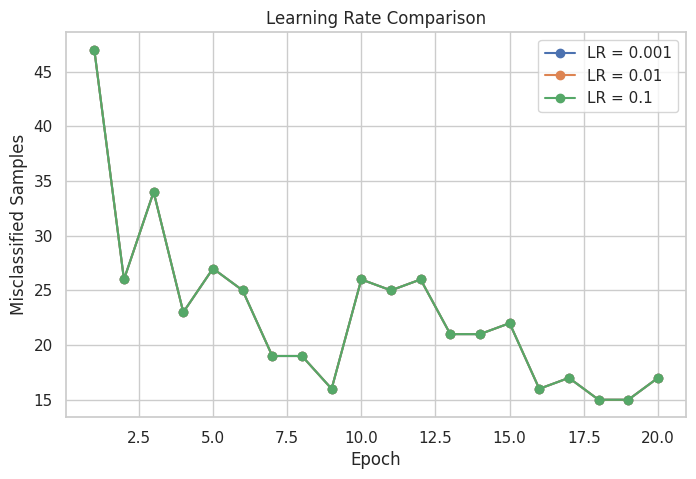

In [ ]:
learning_rates = [0.001, 0.01, 0.1]

plt.figure(figsize=(8,5))

for lr in learning_rates:

    temp_model = Perceptron(
        learning_rate=lr,
        epochs=20
    )

    temp_model.fit(X_train, y_train)

    plt.plot(range(1, len(temp_model.errors)+1),
             temp_model.errors,
             marker='o',
             label=f"LR = {lr}")

plt.xlabel("Epoch")
plt.ylabel("Misclassified Samples")
plt.title("Learning Rate Comparison")

plt.legend()

plt.grid(True)

plt.savefig("learning_rate_comparison.eps",
            format="eps",
            bbox_inches="tight")

plt.show()


TRAINING OR GATE

Epoch 1

Update 1
Weights : [0. 0.]
Bias : -1

Update 2
Weights : [0. 1.]
Bias : 0

Epoch 2

Update 3
Weights : [0. 1.]
Bias : -1

Update 4
Weights : [1. 1.]
Bias : 0

Epoch 3

Update 5
Weights : [1. 1.]
Bias : -1

Epoch 4

Training Converged.


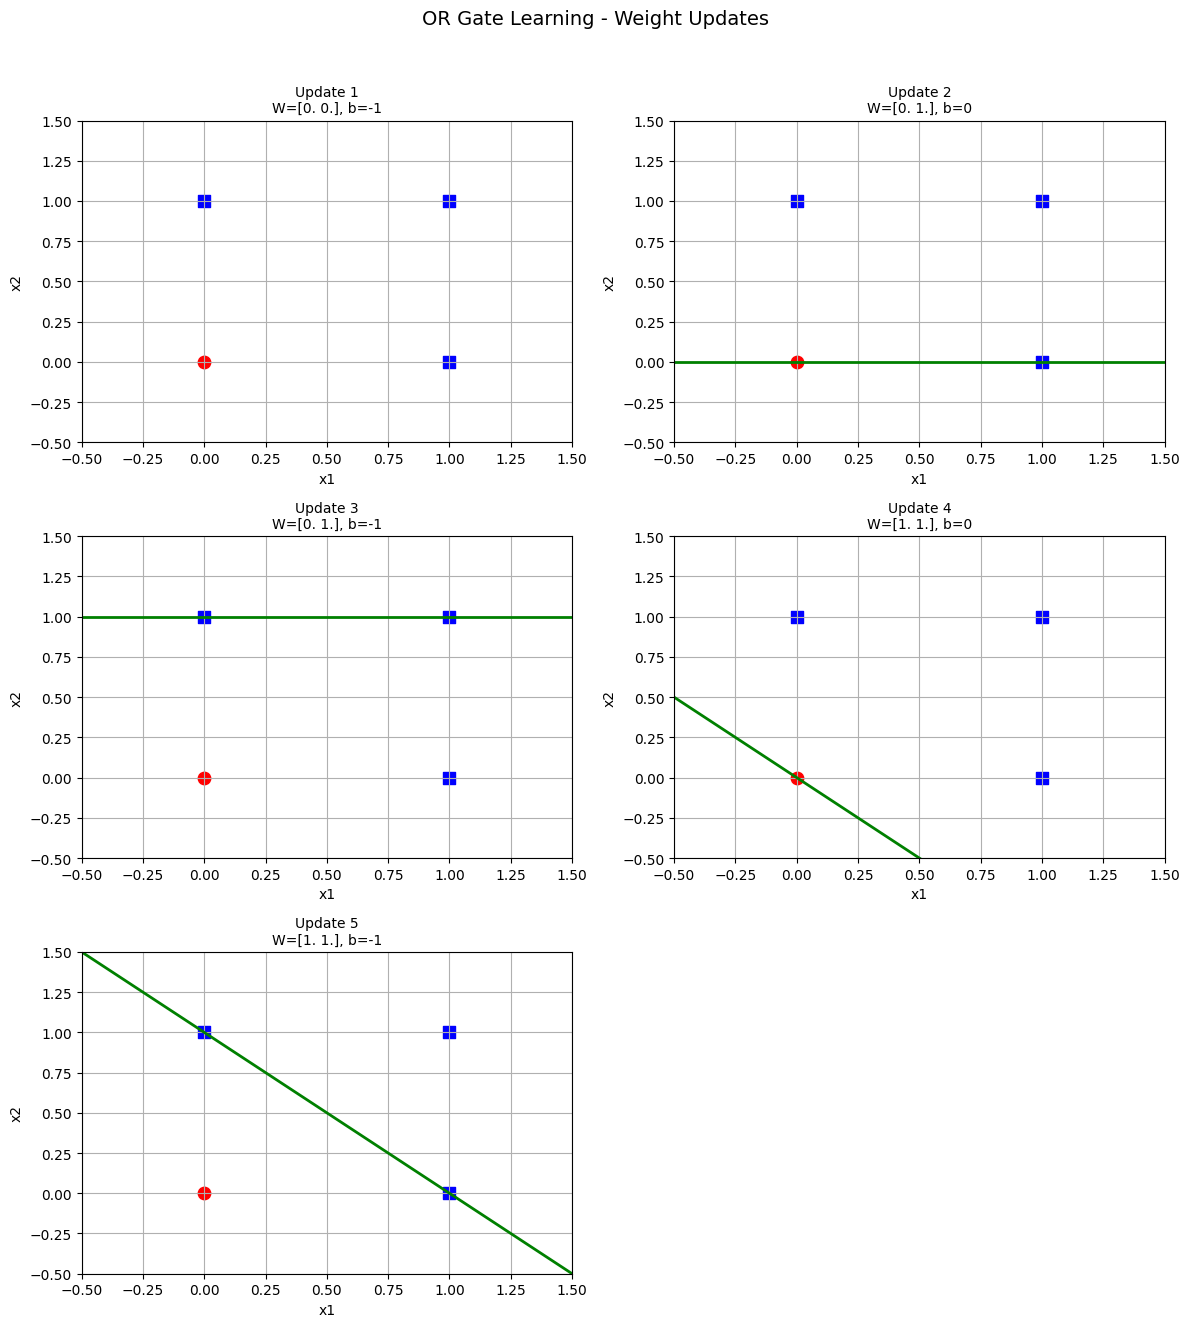


TRAINING AND GATE

Epoch 1

Update 1
Weights : [0. 0.]
Bias : -1

Update 2
Weights : [1. 1.]
Bias : 0

Epoch 2

Update 3
Weights : [1. 1.]
Bias : -1

Update 4
Weights : [1. 0.]
Bias : -2

Update 5
Weights : [2. 1.]
Bias : -1

Epoch 3

Update 6
Weights : [2. 0.]
Bias : -2

Update 7
Weights : [1. 0.]
Bias : -3

Update 8
Weights : [2. 1.]
Bias : -2

Epoch 4

Update 9
Weights : [1. 1.]
Bias : -3

Update 10
Weights : [2. 2.]
Bias : -2

Epoch 5

Update 11
Weights : [2. 1.]
Bias : -3

Epoch 6

Training Converged.


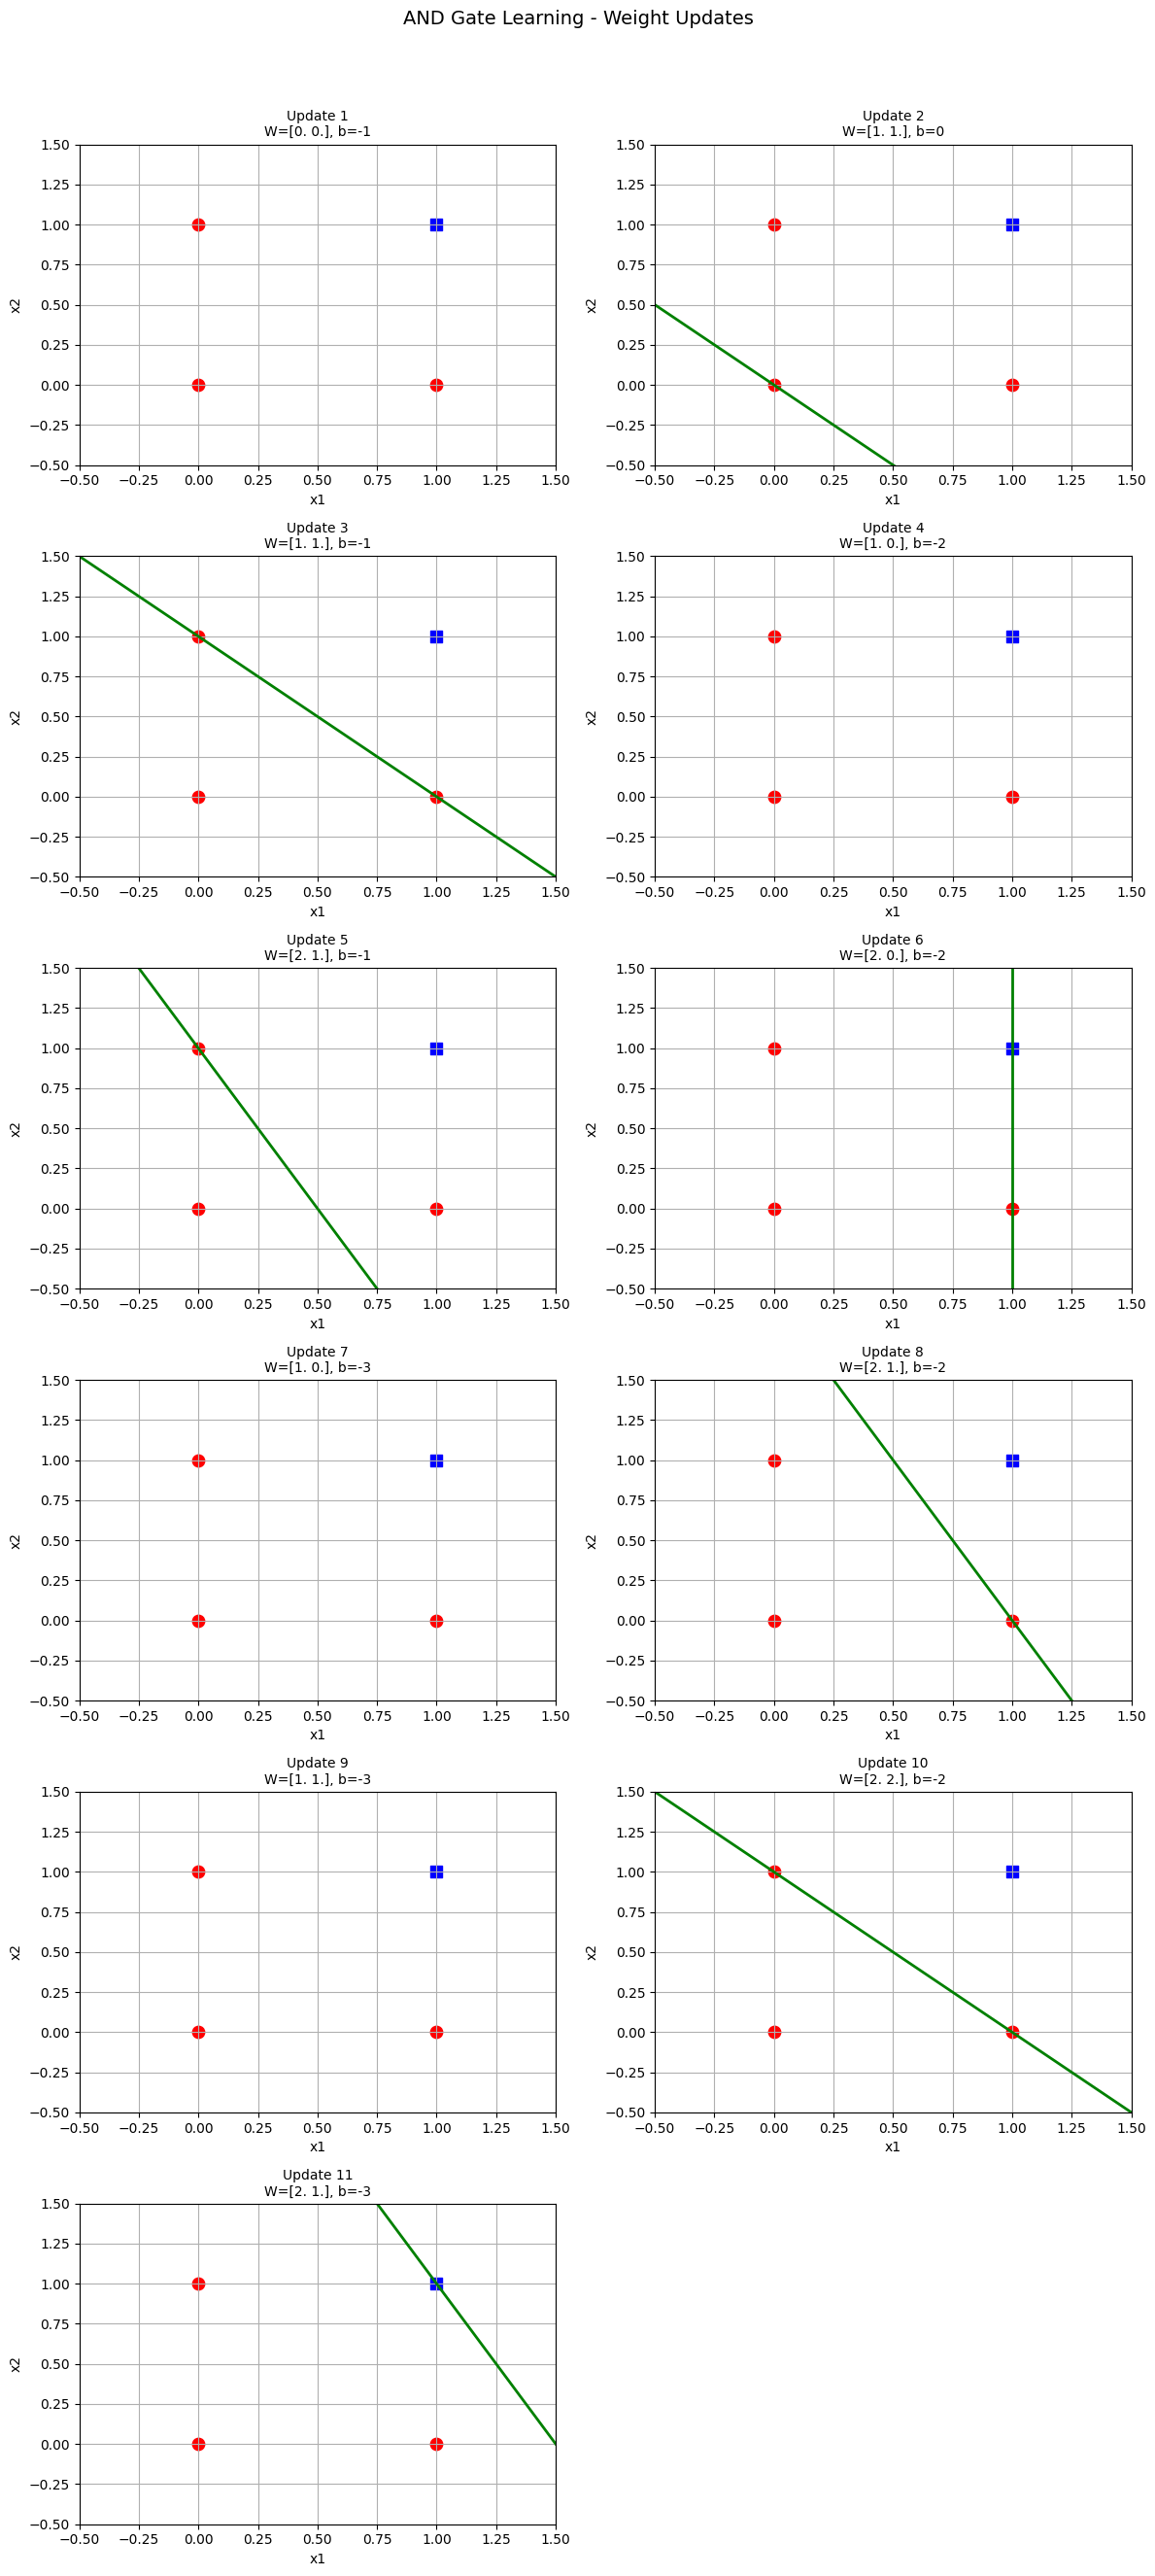



TRAINING NOT GATE
Initial Weight : 0
Initial Bias   : 0

Epoch 1

Update : 1
Input      : 1
Target     : 0
Prediction : 1
Error      : -1
Weight     : -1
Bias       : -1

Epoch 2

Update : 2
Input      : 0
Target     : 1
Prediction : 0
Error      : 1
Weight     : -1
Bias       : 0

Epoch 3

Training Converged.

Final Weight : -1
Final Bias   : 0


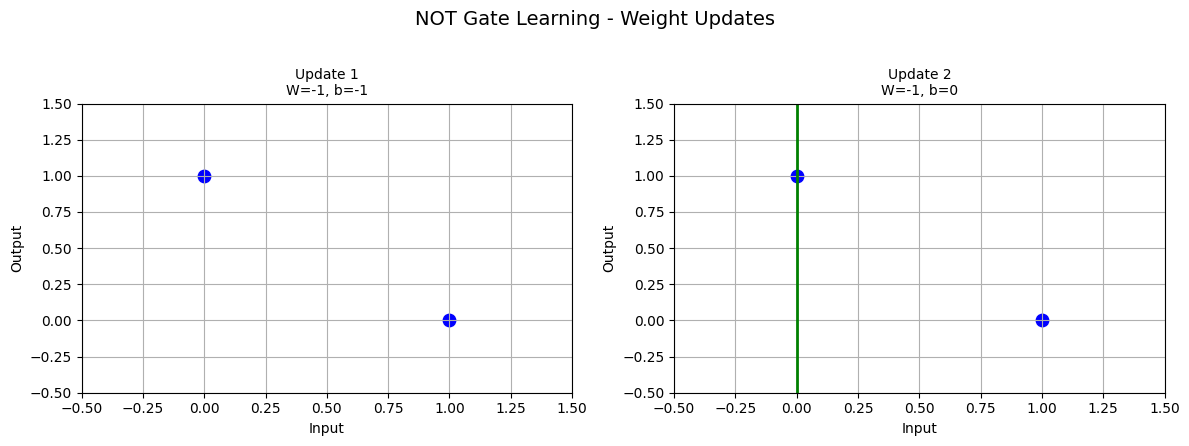



All EPS plots have been saved successfully.
Folder : Perceptron_EPS_Plots
Each gate has ONE figure with all weight-update boundaries
shown as individual subplots (grid layout).


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import os
import math

# ==========================================================
# Create folder to store EPS plots
# ==========================================================
output_folder = "Perceptron_EPS_Plots"
os.makedirs(output_folder, exist_ok=True)


# ==========================================================
# Step Activation Function
# ==========================================================
def step(x):
    if x >= 0:
        return 1
    else:
        return 0


# ==========================================================
# Draw one subplot (2D gates - AND / OR)
# ==========================================================
def draw_subplot_2d(ax, X, y, weights, bias, title):

    for i in range(len(X)):

        if y[i] == 0:
            ax.scatter(X[i][0], X[i][1], color="red",
                       marker="o", s=80,
                       label="Class 0" if i == 0 else "")
        else:
            ax.scatter(X[i][0], X[i][1], color="blue",
                       marker="s", s=80,
                       label="Class 1" if i == 1 else "")

    x_line = np.linspace(-0.5, 1.5, 100)

    if weights[1] != 0:
        y_line = -(weights[0] * x_line + bias) / weights[1]
        ax.plot(x_line, y_line, color="green", linewidth=2)

    elif weights[0] != 0:
        ax.axvline(-bias / weights[0], color="green", linewidth=2)

    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_title(title, fontsize=10)
    ax.grid(True)


# ==========================================================
# Draw one subplot (1D gate - NOT)
# ==========================================================
def draw_subplot_1d(ax, X, y, weight, bias, title):

    ax.scatter(X, y, s=80, color="blue")

    if weight != 0:
        boundary = -bias / weight
        ax.axvline(boundary, color="green", linewidth=2)

    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    ax.set_xlabel("Input")
    ax.set_ylabel("Output")
    ax.set_title(title, fontsize=10)
    ax.grid(True)


# ==========================================================
# Build a grid figure of subplots (one per weight update)
# and save it as a SINGLE EPS file for the gate
# ==========================================================
def build_grid_figure(snapshots, draw_fn, X, y, gate_name):

    n = len(snapshots)

    ncols = 2 if n > 1 else 1
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(6 * ncols, 4.5 * nrows)
    )

    # Normalize axes to a flat list regardless of nrows/ncols
    if n == 1:
        axes_list = [axes]
    else:
        axes_list = np.array(axes).reshape(-1)

    for idx, (weights_or_weight, bias) in enumerate(snapshots):
        ax = axes_list[idx]
        title = f"Update {idx + 1}\nW={weights_or_weight}, b={bias}"
        draw_fn(ax, X, y, weights_or_weight, bias, title)

    # Hide any unused subplot slots
    for idx in range(n, len(axes_list)):
        axes_list[idx].axis("off")

    fig.suptitle(f"{gate_name} Gate Learning - Weight Updates", fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.96])

    fig.savefig(
        os.path.join(output_folder, f"{gate_name}_Gate.eps"),
        format="eps",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)


# ==========================================================
# Perceptron Training Function (AND / OR - 2 inputs)
# ==========================================================
def perceptron_train(X, y, gate_name,
                     learning_rate=1,
                     epochs=20):

    weights = np.zeros(X.shape[1])
    bias = 0

    update = 0
    snapshots = []   # store (weights_copy, bias) after every update

    print("\n" + "=" * 60)
    print("TRAINING", gate_name, "GATE")
    print("=" * 60)

    for epoch in range(epochs):

        print("\nEpoch", epoch + 1)

        error_count = 0

        for i in range(len(X)):

            net = np.dot(X[i], weights) + bias
            prediction = step(net)
            error = y[i] - prediction

            if error != 0:

                weights = weights + learning_rate * error * X[i]
                bias = bias + learning_rate * error

                update += 1
                error_count += 1

                print("\nUpdate", update)
                print("Weights :", weights)
                print("Bias :", bias)

                snapshots.append((weights.copy(), bias))

        if error_count == 0:
            print("\nTraining Converged.")
            break

    build_grid_figure(snapshots, draw_subplot_2d, X, y, gate_name)


# ==========================================================
# NOT Gate (single input) - all updates as subplots in one figure
# ==========================================================
def perceptron_not(X, y,
                   learning_rate=1,
                   epochs=20):

    weight = 0
    bias = 0

    update = 0
    snapshots = []   # store (weight, bias) after every update

    print("\n")
    print("=" * 60)
    print("TRAINING NOT GATE")
    print("=" * 60)

    print("Initial Weight :", weight)
    print("Initial Bias   :", bias)

    for epoch in range(epochs):

        print("\nEpoch", epoch + 1)

        error_count = 0

        for i in range(len(X)):

            net = weight * X[i][0] + bias
            prediction = step(net)
            error = y[i] - prediction

            if error != 0:

                weight = weight + learning_rate * error * X[i][0]
                bias = bias + learning_rate * error

                update += 1

                print("\nUpdate :", update)
                print("Input      :", X[i][0])
                print("Target     :", y[i])
                print("Prediction :", prediction)
                print("Error      :", error)
                print("Weight     :", weight)
                print("Bias       :", bias)

                snapshots.append((weight, bias))

                error_count += 1

        if error_count == 0:
            print("\nTraining Converged.")
            break

    print("\nFinal Weight :", weight)
    print("Final Bias   :", bias)

    build_grid_figure(snapshots, draw_subplot_1d, X, y, "NOT")


# ==========================================================
# OR Gate Dataset
# ==========================================================
X_or = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y_or = np.array([
    0,
    1,
    1,
    1
])

perceptron_train(
    X_or,
    y_or,
    "OR"
)


# ==========================================================
# AND Gate Dataset
# ==========================================================
X_and = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y_and = np.array([
    0,
    0,
    0,
    1
])

perceptron_train(
    X_and,
    y_and,
    "AND"
)


# ==========================================================
# NOT Gate Dataset
# ==========================================================
X_not = np.array([
    [0],
    [1]
])

y_not = np.array([
    1,
    0
])

perceptron_not(
    X_not,
    y_not
)

print("\n")
print("=" * 60)
print("All EPS plots have been saved successfully.")
print("Folder :", output_folder)
print("Each gate has ONE figure with all weight-update boundaries")
print("shown as individual subplots (grid layout).")
print("=" * 60)